## 堆叠柱状图适合同时呈现多组数据的数值大小与占比情况，适合展示有组合关系的数据。
	
### 例如展示同一省份多个地区的经济数据（体现各地区数据占比，也可组合体现全省数据），或者多种能源的碳排放情况（可体现各种类型能源占比，也可组合体现总排放）~


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 设置样式
try:
    plt.style.use("scatter.mplstyle")
except:
    pass
# 使用Nature常用的无衬线字体，Ubuntu系统兼容
plt.rcParams["font.sans-serif"] = ["Liberation Sans", "Arial", "Helvetica", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

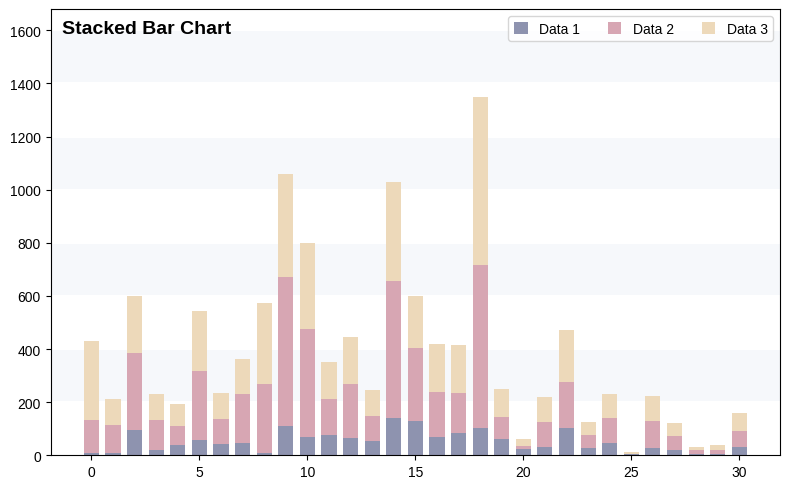

In [2]:
# Create canvas
fig, ax = plt.subplots(figsize=(8, 5), dpi=100)

# Sub-labels (categories for each data group)
sublabel = ["Data 1", "Data 2", "Data 3"]  
np.random.seed(2)  # Fix random seed

# Define colors (colors for 4 data groups)
color = ["#8e93af", "#d7a6b3", "#edd9ba", "#9dc1c5"]  

# Initialize data (two methods, using the second group, first group can be ignored)
# Method 1 (overwritten, for demonstration only)
# x = np.arange(24)
# value = []
# for i in range(4):
#     p1 = np.random.uniform(0.2, 0.8)
#     p2 = np.random.uniform(1, 10)
#     p3 = np.random.uniform(1, 3)
#     value.append(p3*np.sin(p1*(x-p2))+p3)
# value = np.array(value).T
# bottom_values = np.zeros(24)

# Method 2 (actually used data)
x = np.arange(31)
value = np.array([[8, 124, 298], [8, 106, 99], [95, 291, 214], [19, 113, 99], [37, 75, 81], [59, 260, 225], [44, 94, 95],
                  [47, 184, 131], [7, 262, 303], [111, 560, 389], [68, 409, 322], [78, 133, 139], [66, 203, 176], [53, 94, 97], [139, 518, 370],
                  [128, 276, 197], [70, 170, 179], [84, 152, 178], [101, 614, 634], [60, 84, 107], [22, 14, 27], [31, 95, 95], [104, 173, 194],
                  [28, 48, 48], [46, 93, 91], [3, 3, 8], [28, 100, 96], [21, 50, 51], [4, 14, 14], [5, 15, 17], [30, 60, 70]])
bottom_values = np.zeros(31)

# Draw stacked bar chart
for i in range(len(sublabel)):
    ax.bar(
        x, 
        value[:, i],  # Values for each group
        width=0.7,    # Bar width
        color=color[i],  # Color
        label=sublabel[i],  # Legend label
        bottom=bottom_values,  # Stacking base
        zorder=2  # Layer order (ensure above grid)
    )
    # Update base for next layer (accumulate current group values)
    bottom_values += value[:, i]

# Set Y-axis grid (uncomment if needed)
# ax.set_ylim(0, 14)  
ax.grid(axis='y', linestyle='-', linewidth=1.5, color="#ffffff", zorder=1)

# Color Y-axis tick intervals (alternating colors)
yticks = ax.get_yticks()
for i in range(len(yticks) - 1):
    if i % 2 == 1:  # Alternate color for every other row
        ax.axhspan(yticks[i], yticks[i + 1], facecolor="#f6f8fb")

# Add title
ax.text(
    0.015,  # Horizontal position (axes coordinates)
    0.975,  # Vertical position (axes coordinates)
    "Stacked Bar Chart", 
    fontsize=14,
    fontweight="bold",
    ha="left",   # Horizontal alignment
    va="top",    # Vertical alignment
    transform=ax.transAxes  # Use axes coordinate system
)

# Set legend
ax.legend(
    ncols=4,  # Number of legend columns
    loc="upper right",  # Position
    handleheight=1, 
    handlelength=1
)

# Optimize layout and display
plt.tight_layout()

plt.savefig('./Stacked Bar Chart.pdf', dpi=300, bbox_inches='tight')
plt.show()